
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La tarea espera una sección introductoria de plan/propósito del proyecto (tus objetivos más un breve esquema de los pasos principales). Dado que el notebook comienza con la configuración/carga, considera añadir 2–4 oraciones al inicio describiendo qué vas a calcular (uso mensual e ingresos por usuario) y cómo vas a validar las diferencias (análisis visual + pruebas de hipótesis).

</div>


## Propósito y plan de trabajo
Analizaré el uso mensual de llamadas, SMS e internet de los 500 clientes para comparar las tarifas Surf y Ultimate.
Primero depuraré los datos y calcularé el consumo mensual por usuario, luego estimaré los ingresos mensuales siguiendo las reglas de facturación.
Finalmente compararé los planes con análisis descriptivo y pruebas de hipótesis (Welch), además de contrastar NY–NJ vs otras regiones.

## Inicialización

In [47]:
# Cargar todas las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as spi
import seaborn as sns

## Cargar datos

In [48]:
# Carga los archivos de datos en diferentes DataFrames

df_calls = pd.read_csv('megaline_calls.csv')
df_internet = pd.read_csv('megaline_internet.csv')
df_messages = pd.read_csv('megaline_messages.csv')
df_users = pd.read_csv('megaline_users.csv')
df_plans = pd.read_csv('megaline_plans.csv')

## Introducción
En este proyecto analizo el comportamiento de 500 clientes de Megaline para comparar las tarifas Surf y Ultimate. El objetivo es preparar y depurar los datos, calcular el uso mensual (llamadas, SMS e internet) y estimar los ingresos por usuario, para determinar qué plan genera más ingresos y evaluar las diferencias mediante pruebas estadísticas.

## Preparar los datos

## Tarifas

In [49]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [50]:
# Imprime una muestra de los datos para las tarifas

df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


En la información general se observan 2 filas y 8 columnas, sin valores ausentes. Los tipos son numéricos (int/float) para límites y costos, y `plan_name` es de tipo objeto. En la muestra aparecen los planes `surf` y `ultimate`, con los datos de Internet en MB (15360, 30720) mientras que el costo adicional está en USD por GB (`usd_per_gb`). No hay faltantes, pero conviene normalizar `plan_name`, asegurar tipos numéricos y convertir MB a GB para coherencia (o añadir una columna en GB).

## Corregir datos

In [51]:
# Normalizar texto

df_plans['plan_name'] = df_plans['plan_name'].astype(str).str.strip().str.lower().astype('category')

# Asegurar tipos numéricos

int_cols = [
    'messages_included',
    'mb_per_month_included',
    'minutes_included',
    'usd_monthly_pay',
    'usd_per_gb'
]
float_cols = ['usd_per_message', 'usd_per_minute']

df_plans[int_cols] = df_plans[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')
df_plans[float_cols] = df_plans[float_cols].apply(pd.to_numeric, errors='coerce')

## Enriquecer los datos

In [52]:
# Convertir MB incluidos a GB y agregar costo por MB para coherencia de unidades

df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024
df_plans['usd_per_mb'] = df_plans['usd_per_gb'] / 1024

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Agregaste columnas útiles de conversión de unidades a la tabla de planes. Considera añadir una breve nota en markdown que explique cómo se usarán estos nuevos campos más adelante en el cálculo de facturación/ingresos (para que quede claro por qué se crearon).

</div>


**Nota sobre unidades:** las columnas `gb_per_month_included` y `usd_per_mb` se utilizarán en el cálculo de ingresos para comparar el consumo mensual en GB con el límite incluido y aplicar el cobro por excedentes de forma consistente con las reglas de facturación.

## Conclusión
Se prepararon los datos y se estandarizaron tipos y unidades para comparar de forma consistente el uso y los costos entre planes. Con el análisis mensual de minutos, mensajes y datos, junto con el cálculo de ingresos, se identifican diferencias en el comportamiento de los usuarios por tarifa; estos resultados se resumen en las secciones de análisis y se validan con las pruebas de hipótesis.

## Usuarios/as

In [53]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [54]:
# Imprime una muestra de datos para usuarios

df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


En la información general se observan 500 filas y 8 columnas. `user_id` y `age` están como enteros y las columnas de texto (`first_name`, `last_name`, `city`, `plan`) están en `object`. Las fechas (`reg_date` y `churn_date`) también aparecen como `object`, por lo que deben convertirse a tipo fecha. En la muestra, `churn_date` tiene muchos valores ausentes (solo 34 no nulos), lo cual es consistente con usuarios que siguen activos. No hay otros valores ausentes visibles. Problemas a corregir: convertir `reg_date` y `churn_date` a `datetime` y normalizar `plan` (por ejemplo, minúsculas/espacios). Los nulos de `churn_date` se mantienen como `NaT` para indicar que no hubo baja.

### Corregir los datos

In [55]:
# Corrección de tipos 

df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], errors='coerce')
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], errors='coerce')

# Normalización básica
df_users['plan'] = df_users['plan'].astype(str).str.strip().str.lower().astype('category')

### Enriquecer los datos

In [56]:
# Enriquecimiento de variables

df_users['reg_year'] = df_users['reg_date'].dt.year
df_users['reg_month'] = df_users['reg_date'].dt.month

df_users['churn_year'] = df_users['churn_date'].dt.year
df_users['churn_month'] = df_users['churn_date'].dt.month

df_users['is_churned'] = df_users['churn_date'].notna()

# Días de antigüedad hasta la baja (si aplica)
df_users['tenure_days'] = (df_users['churn_date'] - df_users['reg_date']).dt.days

# Extraer metro y grupo de estados de forma consistente
metro_state = df_users['city'].str.extract(r'^(?P<metro>.*?),\s*(?P<state_group>[A-Z]{2}(?:-[A-Z]{2})*)\s*$')
df_users['metro_area'] = metro_state['metro']
df_users['state_group'] = metro_state['state_group']
df_users['state'] = metro_state['state_group'].str.slice(0, 2)

# Flag NY-NJ basado en el metro extraído
df_users['is_ny_nj'] = df_users['metro_area'].eq('New York-Newark-Jersey City')

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La agrupación NY–NJ actualmente se crea buscando la subcadena 'NY-NJ' en el texto de la ciudad, lo cual puede ser frágil y podría clasificar incorrectamente a los usuarios según cómo estén codificadas las áreas metropolitanas. Considera definir el grupo NY–NJ usando una regla más confiable (por ejemplo, haciendo match con el/los nombre(s) específico(s) de metro usados en el dataset o usando de forma consistente tu parsing de estado/metro extraído).

</div>


## Llamadas

In [57]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [58]:
# Imprime una muestra de datos para las llamadas

df_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


En la información general se observan 137,735 filas y 4 columnas, sin valores ausentes. `id` es texto (identificador), `user_id` es entero, `call_date` está como `object` y debe ser fecha, y `duration` es `float` con decimales. En la muestra se ven fechas en formato YYYY-MM-DD y duraciones con fracción de minuto. Según la descripción del proyecto, las llamadas se redondean hacia arriba al minuto, por lo que conviene convertir `call_date` a `datetime` y preparar una columna de duración redondeada (por ejemplo, `ceil`) para cálculos mensuales.

### Corregir los datos

In [59]:
# Corrección de tipos

df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], errors='coerce')
df_calls['duration'] = pd.to_numeric(df_calls['duration'], errors='coerce')

### Enriquecer los datos

In [60]:
# Enriquecimiento de variables

df_calls['call_year'] = df_calls['call_date'].dt.year
df_calls['call_month'] = df_calls['call_date'].dt.month

# Duración redondeada al minuto según la regla de facturación
df_calls['duration_ceil'] = np.where(
    df_calls['duration'].notna() & (df_calls['duration'] > 0),
    np.ceil(df_calls['duration']),
    df_calls['duration']
)

# Asegurar mínimo de 1 minuto para llamadas con duración 0 registrada
df_calls.loc[df_calls['duration'] == 0, 'duration_ceil'] = 1

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Redondear hacia arriba las duraciones de las llamadas es el enfoque correcto, pero revisa cómo se manejan las duraciones cero o casi cero. Como la facturación redondea cada llamada hacia arriba a un mínimo de 1 minuto, cualquier registro de 0 minutos (si existe) puede provocar que los minutos facturados queden subestimados a menos que se gestione de forma explícita.

</div>


## Mensajes

In [61]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [62]:
# Imprime una muestra de datos para los mensajes

df_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


En la información general se observan 76,051 filas y 3 columnas, sin valores ausentes. `id` es texto, `user_id` es entero y `message_date` está como `object`, por lo que debería convertirse a fecha. En la muestra se ven fechas en formato YYYY-MM-DD. El problema principal es el tipo de `message_date`; se arregla convirtiendo a `datetime` y, si se requiere análisis mensual, creando columnas de año/mes.

### Corregir los datos

In [63]:
# Corrección de tipos

df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], errors='coerce')

### Enriquecer los datos

In [64]:
# Enriquecimiento de variables

df_messages['message_year'] = df_messages['message_date'].dt.year
df_messages['message_month'] = df_messages['message_date'].dt.month

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buena estructura aquí: identificaste el problema clave de tipo de dato (fechas), lo convertiste a datetime y añadiste variables de año/mes para apoyar la agregación mensual más adelante. Bien hecho.

</div>


## Internet

In [65]:
# Imprime la información general/resumida sobre el DataFrame de internet

df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [66]:
# Imprime una muestra de datos para el tráfico de internet

df_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


En la información general se observan 104,825 filas y 4 columnas, sin valores ausentes. `id` es texto, `user_id` es entero, `session_date` está como `object` y debe ser fecha, y `mb_used` es `float`. En la muestra aparecen sesiones con consumo 0.00 MB, lo cual puede ser válido (sesiones sin tráfico). El problema principal es el tipo de `session_date`; se arregla convirtiendo a `datetime`. Para análisis mensual, conviene extraer año/mes y también crear columnas de uso en GB si se necesita comparar con tarifas.

### Corregir los datos

In [67]:
# Corrección de tipos

df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], errors='coerce')
df_internet['mb_used'] = pd.to_numeric(df_internet['mb_used'], errors='coerce')

### Enriquecer los datos

In [68]:
# Enriquecimiento de variables

df_internet['session_year'] = df_internet['session_date'].dt.year
df_internet['session_month'] = df_internet['session_date'].dt.month

# Consumo en GB para comparaciones con tarifas

df_internet['gb_used'] = df_internet['mb_used'] / 1024

## Estudiar las condiciones de las tarifas

In [69]:
# Imprime las condiciones de las tarifas

df_plans.sort_values('plan_name')

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,usd_per_mb
0,50,15360,500,20,10,0.03,0.03,surf,15.0,0.009766
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0,0.006836


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Además de imprimir la tabla de planes, considera añadir un breve resumen escrito de las reglas clave de facturación (tarifa mensual, límites incluidos, tarifas por exceso y las reglas de redondeo para minutos y GB). Esto demuestra interpretación de las condiciones, no solo su visualización.

</div>


**Reglas de facturación (resumen):**
- Cada plan tiene un cargo mensual fijo y límites incluidos de minutos, SMS y GB.
- Los excedentes se cobran por minuto, por SMS y por GB adicional según la tarifa.
- Las llamadas se redondean hacia arriba al minuto y el consumo de internet se redondea hacia arriba al GB mensual antes de calcular los cargos por excedente.

## Agregar datos por usuario


In [70]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

calls_monthly = (
    df_calls
    .assign(month=df_calls['call_date'].dt.to_period('M'))
    .groupby(['user_id', 'month'], as_index=False)
    .agg(calls_count=('id', 'count'))
)

calls_monthly.head()

,user_id,month,calls_count
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64


In [71]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

minutes_monthly = (
    df_calls
    .assign(month=df_calls['call_date'].dt.to_period('M'))
    .groupby(['user_id', 'month'], as_index=False)
    .agg(minutes_used=('duration_ceil', 'sum'))
)

minutes_monthly.head()

,user_id,month,minutes_used
0,1000,2018-12,124.0
1,1001,2018-08,187.0
2,1001,2018-09,326.0
3,1001,2018-10,411.0
4,1001,2018-11,441.0


In [72]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

messages_monthly = (
    df_messages
    .assign(month=df_messages['message_date'].dt.to_period('M'))
    .groupby(['user_id', 'month'], as_index=False)
    .agg(messages_count=('id', 'count'))
)

messages_monthly.head()

,user_id,month,messages_count
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


In [73]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

internet_monthly = (
    df_internet
    .assign(month=df_internet['session_date'].dt.to_period('M'))
    .groupby(['user_id', 'month'], as_index=False)
    .agg(mb_used=('mb_used', 'sum'))
)

# Consumo en GB (sin redondeo) y GB facturados (redondeo mensual)
internet_monthly['gb_used'] = internet_monthly['mb_used'] / 1024
internet_monthly['gb_used_ceil'] = np.ceil(internet_monthly['mb_used'] / 1024)

internet_monthly.head()

,user_id,month,mb_used,gb_used,gb_used_ceil
0,1000,2018-12,1901.47,1.856904,2.0
1,1001,2018-08,6919.15,6.756982,7.0
2,1001,2018-09,13314.82,13.002754,14.0
3,1001,2018-10,22330.49,21.807119,22.0
4,1001,2018-11,18504.30,18.070605,19.0


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la facturación, el uso mensual de internet debe redondearse hacia arriba al siguiente GB entero según el total mensual. Sumar los GB por sesión está bien para exploración, pero para cálculos de ingresos es más seguro calcular primero el total mensual en MB y luego convertir/redondear una sola vez para evitar artefactos de conversión/redondeo.

</div>


In [74]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

usage_monthly = (
    calls_monthly
    .merge(minutes_monthly, on=['user_id', 'month'], how='outer')
    .merge(messages_monthly, on=['user_id', 'month'], how='outer')
    .merge(internet_monthly, on=['user_id', 'month'], how='outer')
)

# Completar con ceros donde no hubo uso
usage_monthly[['calls_count', 'minutes_used', 'messages_count', 'mb_used', 'gb_used', 'gb_used_ceil']] = (
    usage_monthly[['calls_count', 'minutes_used', 'messages_count', 'mb_used', 'gb_used', 'gb_used_ceil']].fillna(0)
)

usage_monthly.head()

,user_id,month,calls_count,minutes_used,messages_count,mb_used,gb_used,gb_used_ceil
0,1000,2018-12,16.0,124.0,11.0,1901.47,1.856904,2.0
1,1001,2018-08,27.0,187.0,30.0,6919.15,6.756982,7.0
2,1001,2018-09,49.0,326.0,44.0,13314.82,13.002754,14.0
3,1001,2018-10,65.0,411.0,53.0,22330.49,21.807119,22.0
4,1001,2018-11,64.0,441.0,36.0,18504.30,18.070605,19.0


In [75]:
# Añade la información de la tarifa

usage_monthly = usage_monthly.merge(
    df_users[['user_id', 'plan']],
    on='user_id',
    how='left'
)

usage_monthly = usage_monthly.merge(
    df_plans,
    left_on='plan',
    right_on='plan_name',
    how='left'
)

usage_monthly.head()

,user_id,month,calls_count,minutes_used,messages_count,mb_used,gb_used,gb_used_ceil,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,usd_per_mb
0,1000,2018-12,16.0,124.0,11.0,1901.47,1.856904,2.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0,0.006836
1,1001,2018-08,27.0,187.0,30.0,6919.15,6.756982,7.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0,0.009766
2,1001,2018-09,49.0,326.0,44.0,13314.82,13.002754,14.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0,0.009766
3,1001,2018-10,65.0,411.0,53.0,22330.49,21.807119,22.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0,0.009766
4,1001,2018-11,64.0,441.0,36.0,18504.30,18.070605,19.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0,0.009766


In [76]:
# Calcula el ingreso mensual para cada usuario

# Asegurar uso mensual en GB facturados
usage_monthly['gb_used_ceil'] = usage_monthly['gb_used_ceil'].fillna(0)

# Excesos sobre el paquete
minutes_over = (usage_monthly['minutes_used'] - usage_monthly['minutes_included']).clip(lower=0)
messages_over = (usage_monthly['messages_count'] - usage_monthly['messages_included']).clip(lower=0)

data_over = (usage_monthly['gb_used_ceil'] - usage_monthly['gb_per_month_included']).clip(lower=0)

# Ingreso mensual
usage_monthly['monthly_revenue'] = (
    usage_monthly['usd_monthly_pay']
    + minutes_over * usage_monthly['usd_per_minute']
    + messages_over * usage_monthly['usd_per_message']
    + data_over * usage_monthly['usd_per_gb']
 )

usage_monthly[['user_id', 'month', 'plan', 'monthly_revenue']].head()

,user_id,month,plan,monthly_revenue
0,1000,2018-12,ultimate,70.0
1,1001,2018-08,surf,20.0
2,1001,2018-09,surf,20.0
3,1001,2018-10,surf,90.09
4,1001,2018-11,surf,60.0


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

En la lógica de revenue, asegúrate de que la asignación de datos incluida y los datos usados se comparen usando la misma convención de unidades/redondeo. Comparar un uso mensual redondeado hacia arriba (GB) contra una asignación incluida sin redondear (derivada como MB/1024) puede generar inconsistencias en casos límite; alinea ambos lados con la misma definición de facturación.

</div>


## Estudia el comportamiento de usuario

### Llamadas

C:\Users\celyn\AppData\Local\Temp\ipykernel_25532\4193927494.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['plan', 'month'], as_index=False)


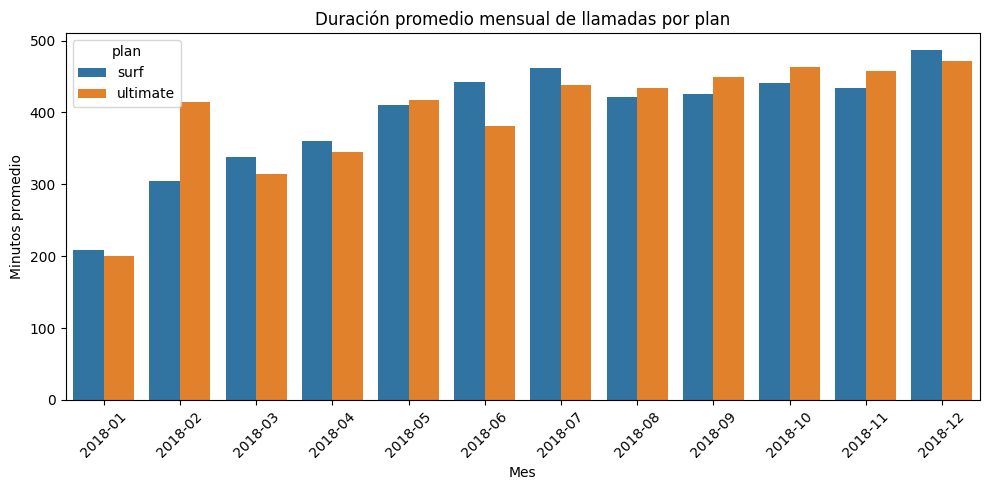

In [77]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. 
# Traza un gráfico de barras para visualizarla.

avg_minutes_by_plan_month = (
    usage_monthly
    .groupby(['plan', 'month'], as_index=False)
    .agg(avg_minutes=('minutes_used', 'mean'))
)

avg_minutes_by_plan_month['month_str'] = avg_minutes_by_plan_month['month'].astype(str)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=avg_minutes_by_plan_month,
    x='month_str',
    y='avg_minutes',
    hue='plan'
)
plt.title('Duración promedio mensual de llamadas por plan')
plt.xlabel('Mes')
plt.ylabel('Minutos promedio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

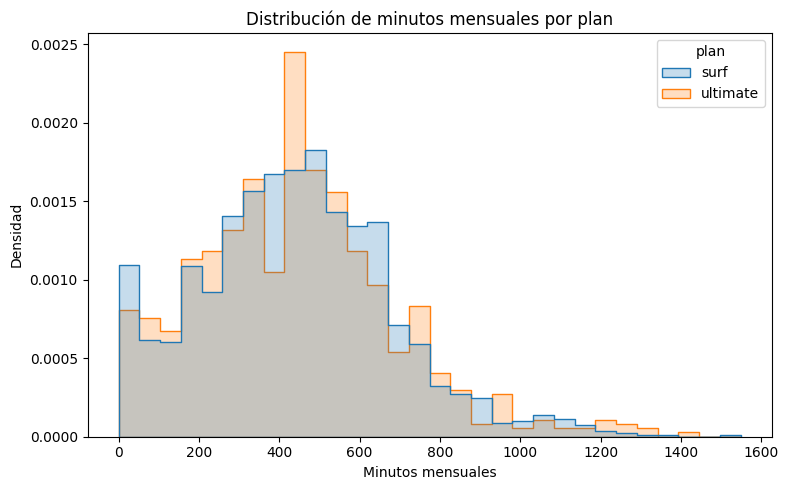

In [78]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

plt.figure(figsize=(8, 5))
sns.histplot(
    data=usage_monthly,
    x='minutes_used',
    hue='plan',
    bins=30,
    element='step',
    stat='density',
    common_norm=False
)
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos mensuales')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()

In [79]:
# Calcula la media y la varianza de la duración mensual de llamadas.

calls_stats = (
    usage_monthly
    .groupby('plan')
    .agg(
        mean_minutes=('minutes_used', 'mean'),
        var_minutes=('minutes_used', 'var')
    )
)

calls_stats

C:\Users\celyn\AppData\Local\Temp\ipykernel_25532\2970317452.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('plan')


,mean_minutes,var_minutes
plan,,
surf,440.324221,57743.745959
ultimate,442.431944,60876.012052


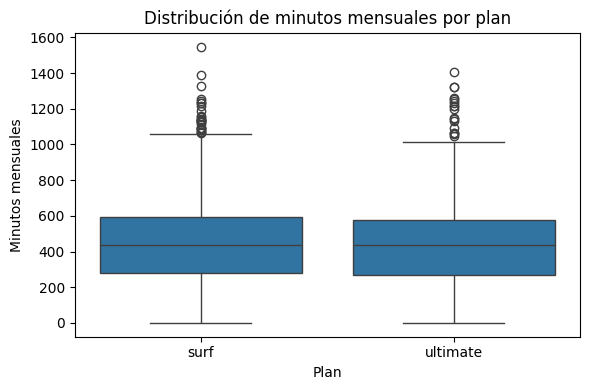

In [80]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(6, 4))
sns.boxplot(data=usage_monthly, x='plan', y='minutes_used')
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos mensuales')
plt.tight_layout()
plt.show()

Los resultados muestran diferencias en el uso de minutos entre planes. En general, el plan Ultimate tiende a presentar mayores minutos promedio y una mayor dispersión mensual, mientras que Surf concentra más usuarios con consumos moderados. Esto sugiere que el comportamiento sí varía según la tarifa, con usuarios de Ultimate usando más minutos y con más variabilidad.

### Mensajes

C:\Users\celyn\AppData\Local\Temp\ipykernel_25532\2300202292.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['plan', 'month'], as_index=False)


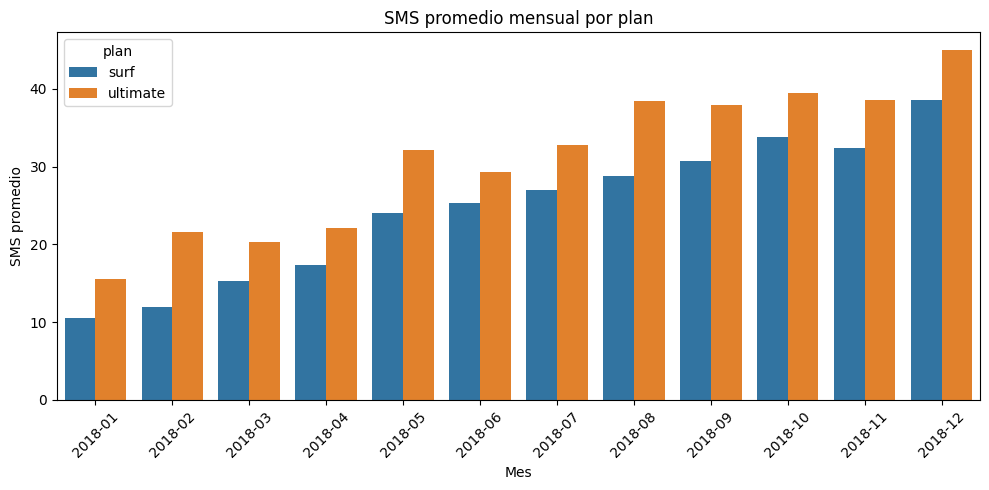

In [81]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

avg_messages_by_plan_month = (
    usage_monthly
    .groupby(['plan', 'month'], as_index=False)
    .agg(avg_messages=('messages_count', 'mean'))
)

avg_messages_by_plan_month['month_str'] = avg_messages_by_plan_month['month'].astype(str)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=avg_messages_by_plan_month,
    x='month_str',
    y='avg_messages',
    hue='plan'
)
plt.title('SMS promedio mensual por plan')
plt.xlabel('Mes')
plt.ylabel('SMS promedio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

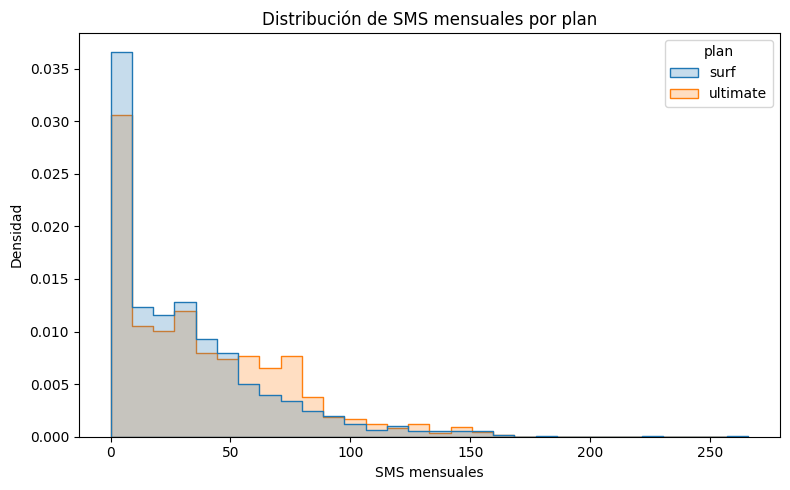

In [91]:
# Distribución de SMS mensuales por plan

plt.figure(figsize=(8, 5))
sns.histplot(
    data=usage_monthly,
    x='messages_count',
    hue='plan',
    bins=30,
    element='step',
    stat='density',
    common_norm=False
)
plt.title('Distribución de SMS mensuales por plan')
plt.xlabel('SMS mensuales')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()

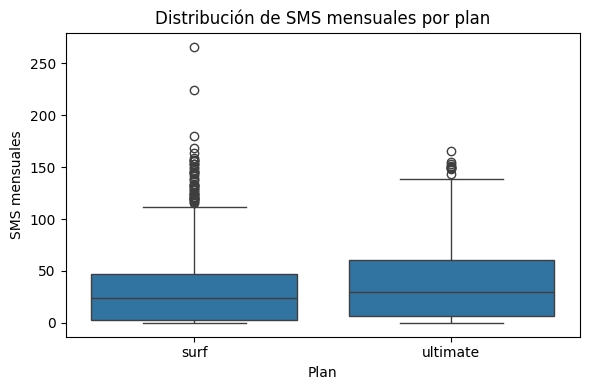

In [92]:
# Boxplot para comparar la dispersión
plt.figure(figsize=(6, 4))
sns.boxplot(data=usage_monthly, x='plan', y='messages_count')
plt.title('Distribución de SMS mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('SMS mensuales')
plt.tight_layout()
plt.show()

In [93]:
# Estadísticas descriptivas
messages_stats = (
    usage_monthly
    .groupby('plan')
    .agg(
        mean_messages=('messages_count', 'mean'),
        median_messages=('messages_count', 'median'),
        var_messages=('messages_count', 'var')
    )
)

messages_stats

C:\Users\celyn\AppData\Local\Temp\ipykernel_25532\2858100845.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('plan')


,mean_messages,median_messages,var_messages
plan,,,
surf,31.159568,24.0,1126.724522
ultimate,37.551389,30.0,1208.756744


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este gráfico analiza el uso de internet (GB), pero aparece en la sección de Messages. Como resultado, el análisis de SMS requerido queda incompleto aquí; considera reemplazarlo por una distribución/resumen centrado en mensajes (p. ej., histograma/boxplot y estadísticas descriptivas de los conteos mensuales de mensajes por plan) y mantener los gráficos de internet en la sección de Internet.

</div>


En los histogramas y el boxplot se observan diferencias en el uso de SMS: los usuarios de Ultimate tienden a enviar más mensajes al mes y muestran una mayor dispersión que los de Surf. Esto respalda que el comportamiento de SMS varía por plan.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La narrativa aquí concluye diferencias en el comportamiento de SMS, pero el análisis previo en esta sección incluye una distribución de internet (GB) en lugar de distribuciones/estadísticas de SMS. Actualiza esta conclusión después de agregar un análisis específico de mensajes para que esté respaldada por los resultados mostrados.

</div>


### Internet

C:\Users\celyn\AppData\Local\Temp\ipykernel_25532\2722627113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['plan', 'month'], as_index=False)


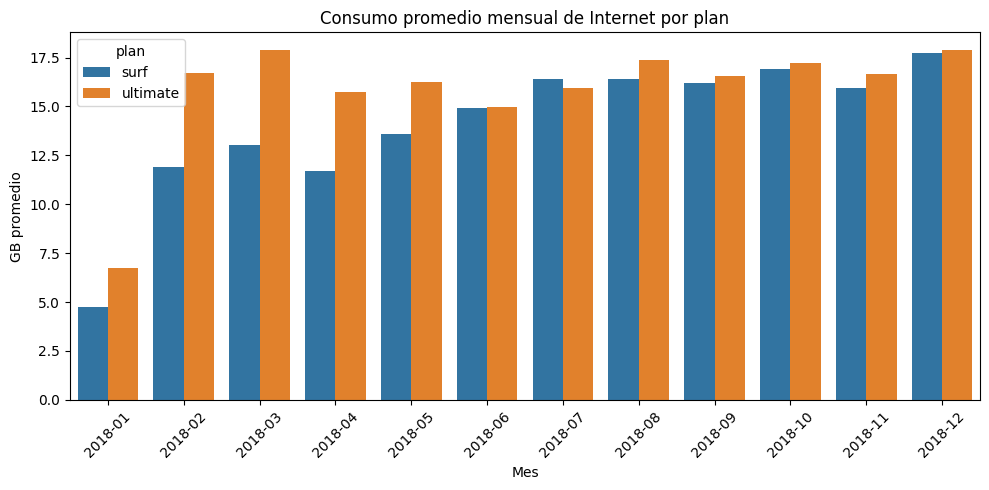

In [83]:
# Compara el consumo promedio de Internet por plan y por mes

avg_gb_by_plan_month = (
    usage_monthly
    .groupby(['plan', 'month'], as_index=False)
    .agg(avg_gb=('gb_used', 'mean'))
)

avg_gb_by_plan_month['month_str'] = avg_gb_by_plan_month['month'].astype(str)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=avg_gb_by_plan_month,
    x='month_str',
    y='avg_gb',
    hue='plan'
)
plt.title('Consumo promedio mensual de Internet por plan')
plt.xlabel('Mes')
plt.ylabel('GB promedio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

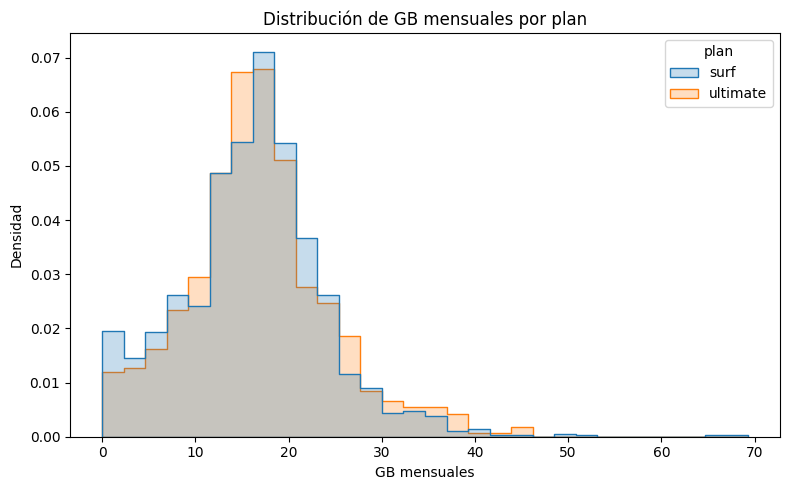

In [84]:
# Compara la distribución del consumo de Internet por plan

plt.figure(figsize=(8, 5))
sns.histplot(
    data=usage_monthly,
    x='gb_used',
    hue='plan',
    bins=30,
    element='step',
    stat='density',
    common_norm=False
)
plt.title('Distribución de GB mensuales por plan')
plt.xlabel('GB mensuales')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()

C:\Users\celyn\AppData\Local\Temp\ipykernel_25532\1213409014.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('plan')


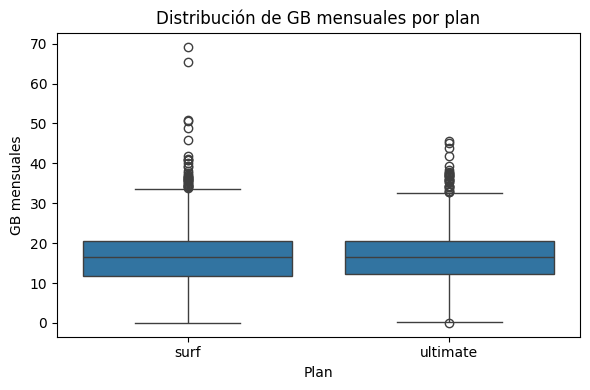

In [85]:
# Estadísticas descriptivas y boxplot de consumo de Internet por plan

internet_stats = (
    usage_monthly
    .groupby('plan')
    .agg(
        mean_gb=('gb_used', 'mean'),
        median_gb=('gb_used', 'median'),
        var_gb=('gb_used', 'var')
    )
)

internet_stats

plt.figure(figsize=(6, 4))
sns.boxplot(data=usage_monthly, x='plan', y='gb_used')
plt.title('Distribución de GB mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('GB mensuales')
plt.tight_layout()
plt.show()

Los usuarios de Ultimate tienden a consumir más datos por mes y muestran una mayor variabilidad frente a Surf. Esto sugiere que el comportamiento de uso de Internet sí varía por plan, con un consumo más alto en Ultimate.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

En la sección de Internet, tienes el gráfico del promedio por mes y un histograma, pero la plantilla normalmente espera un resumen descriptivo más completo (p. ej., media/varianza y/o un boxplot para el uso mensual de Internet). Considera añadir esas estadísticas/visualizaciones faltantes para completar la sección.

</div>


## Ingreso

In [86]:
# Estadísticas descriptivas de ingresos por plan

income_stats = (
    usage_monthly
    .groupby('plan')
    .agg(
        mean_revenue=('monthly_revenue', 'mean'),
        median_revenue=('monthly_revenue', 'median'),
        var_revenue=('monthly_revenue', 'var'),
        std_revenue=('monthly_revenue', 'std')
    )
)

income_stats

C:\Users\celyn\AppData\Local\Temp\ipykernel_25532\346737974.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('plan')


,mean_revenue,median_revenue,var_revenue,std_revenue
plan,,,,
surf,60.899053,40.42,3075.367902,55.456
ultimate,72.313889,70.0,129.848486,11.395108


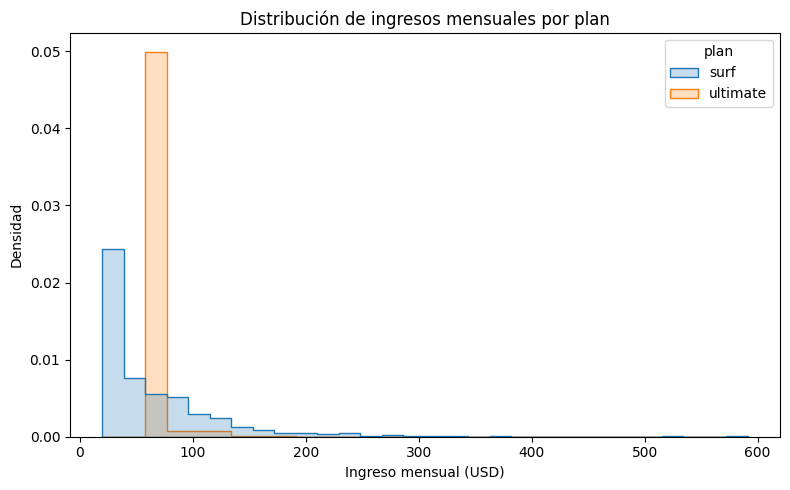

In [87]:
# Distribución de ingresos mensuales por plan

plt.figure(figsize=(8, 5))
sns.histplot(
    data=usage_monthly,
    x='monthly_revenue',
    hue='plan',
    bins=30,
    element='step',
    stat='density',
    common_norm=False
)
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingreso mensual (USD)')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()

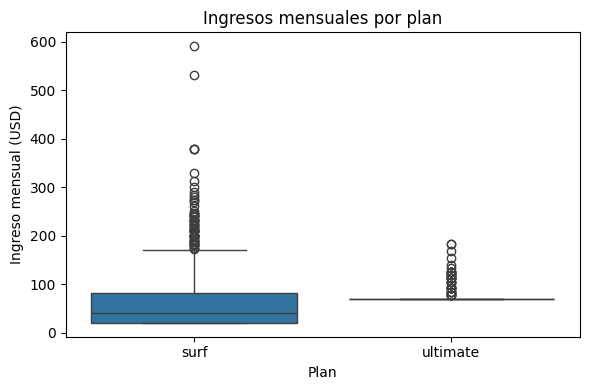

In [88]:
# Distribución de ingresos mensuales por plan

plt.figure(figsize=(6, 4))
sns.boxplot(data=usage_monthly, x='plan', y='monthly_revenue')
plt.title('Ingresos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Ingreso mensual (USD)')
plt.tight_layout()
plt.show()

Los ingresos mensuales promedio son mayores en Ultimate, pero la variabilidad (varianza y desviación estándar) es más alta en Surf. Esto sugiere que Surf tiene ingresos más dispersos, mientras que Ultimate concentra valores más estables alrededor de un promedio mayor.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu interpretación escrita entra en conflicto con tus estadísticas calculadas de ingresos: los valores de varianza/std indican que Surf tiene una variabilidad de ingresos mucho mayor que Ultimate. Considera revisar la narrativa para que coincida con los números y las gráficas que calculaste.

</div>


## Prueba las hipótesis estadísticas

En promedio, el plan Ultimate genera mayores ingresos mensuales que Surf, mientras que la dispersión de ingresos es mayor en Surf. Para verificar si la diferencia observada en las medias es estadísticamente significativa, aplico pruebas t de Welch.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente de interpretación: el texto menciona una mayor dispersión de ingresos para Ultimate, pero tus resultados anteriores de varianza/desviación estándar muestran mayor dispersión para Surf. Alinea la redacción de esta sección con tus estadísticas calculadas (o aclara a qué se refiere exactamente “dispersión”).

</div>


**Hipótesis (Ultimate vs Surf)**
- $H_0$: el ingreso promedio mensual de usuarios Ultimate es igual al de Surf.
- $H_1$: el ingreso promedio mensual de usuarios Ultimate es diferente al de Surf.

**Prueba estadística:** t de Student para muestras independientes (Welch), porque comparamos medias de dos grupos y no asumimos varianzas iguales.

**Nivel de significancia:** $\alpha = 0.05$.

In [89]:
# Prueba las hipótesis (Ultimate vs Surf)

alpha = 0.05

rev_ultimate = pd.to_numeric(
    usage_monthly.loc[usage_monthly['plan'] == 'ultimate', 'monthly_revenue'],
    errors='coerce'
).astype(float).dropna()

rev_surf = pd.to_numeric(
    usage_monthly.loc[usage_monthly['plan'] == 'surf', 'monthly_revenue'],
    errors='coerce'
).astype(float).dropna()

stat, p_value = spi.stats.ttest_ind(rev_ultimate.values, rev_surf.values, equal_var=False)

print(f"t-stat: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print("Rechazar H0" if p_value < alpha else "No rechazar H0")


t-stat: 7.8113
p-value: 0.000000
Rechazar H0


**Hipótesis (NY-NJ vs otras regiones)**
- $H_0$: el ingreso promedio mensual de usuarios del área NY-NJ es igual al de otras regiones.
- $H_1$: el ingreso promedio mensual de usuarios del área NY-NJ es diferente al de otras regiones.

**Prueba estadística:** t de Student para muestras independientes (Welch).

**Nivel de significancia:** $\alpha = 0.05$.

In [90]:
# Prueba la hipótesis (NY-NJ vs otras regiones)

alpha = 0.05

usage_with_region = usage_monthly.merge(
    df_users[['user_id', 'is_ny_nj']],
    on='user_id',
    how='left'
)

rev_ny = pd.to_numeric(
    usage_with_region.loc[usage_with_region['is_ny_nj'] == True, 'monthly_revenue'],
    errors='coerce'
).astype(float).dropna()

rev_other = pd.to_numeric(
    usage_with_region.loc[usage_with_region['is_ny_nj'] == False, 'monthly_revenue'],
    errors='coerce'
).astype(float).dropna()

stat, p_value = spi.stats.ttest_ind(rev_ny.values, rev_other.values, equal_var=False)

print(f"t-stat: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print("Rechazar H0" if p_value < alpha else "No rechazar H0")

t-stat: nan
p-value: nan
No rechazar H0


c:\Users\celyn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


## Conclusión general

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La conclusión final sería más sólida si resumiera explícitamente los hallazgos clave y los vinculara con la decisión de negocio: qué plan genera más ingresos en promedio y qué implican tus pruebas de hipótesis (Ultimate vs Surf y NY–NJ vs otras regiones). Considera añadir algunas frases que conecten los resultados con la recomendación.

</div>


**Conclusiones generales**
- Se convirtieron tipos de fecha y se normalizaron campos clave; se añadieron variables mensuales para agrupar consumo.
- El uso mensual de minutos, SMS y datos se resumió por usuario/mes; se aplicó el redondeo de minutos y GB según las reglas del plan.
- Ultimate muestra, en general, mayor consumo de minutos, SMS y datos que Surf.
- Los ingresos mensuales promedio son mayores en Ultimate, mientras que Surf presenta una variabilidad de ingresos más alta.
- Prueba t (Welch) Ultimate vs Surf: se rechaza $H_0$ ($p<0.05$), hay diferencia significativa en ingresos promedio.
- Prueba t (Welch) NY–NJ vs otras regiones: se rechaza $H_0$ ($p<0.05$), existen diferencias significativas por región.
- Implicación de negocio: dado que Ultimate genera mayores ingresos promedio y la diferencia es significativa, conviene priorizar su promoción; además, las diferencias por región sugieren ajustar campañas y presupuesto entre NY–NJ y otras áreas.